# 04 — Evaluation, Benchmark Comparison & Model Registry

**Team Update 4.1 step 3** (evaluate the model and compare it against the
simple benchmark) **+ the Model Store** (group, package, model card).

| Step | Verify (📸) |
|---|---|
| Champion selection (val macro F1 + High-Risk recall floor, benchmark gate) | selection table |
| Test-set confusion matrix + fairness slices + feature importance | plots below |
| Registry: model group, package, model card | `describe_*` outputs |

Champion rule (design doc): best **validation** macro F1 subject to
High-Risk recall >= floor, then confirmed once on the untouched test split,
and required to beat the benchmark's test macro F1.

## 1. Setup

In [1]:
import os
from pathlib import Path

# CWD depends on the runner: Studio file view starts at the repo root, while
# `jupyter nbconvert` starts in the notebook's directory. Resolve the repo
# root (the dir that contains src/) and work from there.
if (Path.cwd() / "src").is_dir():
    REPO = Path.cwd()
elif (Path.cwd().parent / "src").is_dir():
    REPO = Path.cwd().parent
else:  # fresh Studio file view: clone the repo next to the notebooks dir
    !git clone --quiet https://github.com/University-San-Diego-MAAI/AAI-540-Group-1-Final-Project.git ../repo
    REPO = Path.cwd().parent / "repo"
os.chdir(REPO)
print("repo root:", REPO, "| src/model_common.py:", (REPO / "src" / "model_common.py").is_file())

repo root: /Users/sourangshupal/Downloads/final-project-usd | src/model_common.py: True


In [2]:
%pip install -q "sagemaker<3" xgboost matplotlib

import json
import subprocess
import tarfile

import boto3
import pandas as pd
import sagemaker

region = boto3.Session().region_name
boto_session = boto3.Session(region_name=region)
sm_client = boto_session.client("sagemaker", region_name=region)
s3 = boto3.client("s3", region_name=region)
bucket = sagemaker.Session(boto_session=boto_session).default_bucket()
prefix = "aai-540-g1"

try:
    role = sagemaker.get_execution_role()  # Studio / notebook instance
except Exception:
    # local run (personal account): dedicated project role if present,
    # otherwise the newest SageMaker execution role in the account
    iam = boto3.client("iam", region_name=region)
    by_name = {r["RoleName"]: r for r in iam.list_roles()["Roles"]}
    if "aai-540-g1-execution-role" in by_name:
        picked = "aai-540-g1-execution-role"
    else:
        cands = [n for n in by_name if n.startswith("AmazonSageMaker-ExecutionRole")]
        if not cands:
            raise RuntimeError("no SageMaker execution role found - run scripts/ensure_execution_role.py")
        picked = sorted(cands, key=lambda n: by_name[n]["CreateDate"])[-1]
    account = boto3.client("sts").get_caller_identity()["Account"]
    role = f"arn:aws:iam::{account}:role/{picked}"
print(f"role={role}\nbucket={bucket}")

Note: you may need to restart the kernel to use updated packages.


sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/sourangshupal/Library/Application Support/sagemaker/config.yaml


/Users/sourangshupal/Downloads/final-project-usd/.venv-sm/lib/python3.9/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


/Users/sourangshupal/Downloads/final-project-usd/.venv-sm/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


Couldn't call 'get_role' to get Role ARN from role name final-usd to get Role path.


role=arn:aws:iam::685057748560:role/aai-540-g1-execution-role
bucket=sagemaker-us-east-1-685057748560


## 2. Load results + pick the champion

In [3]:
s3.download_file(bucket, f"{prefix}/artifacts/evaluation/training_comparison.csv",
                 "training_comparison.csv")
s3.download_file(bucket, f"{prefix}/artifacts/evaluation/benchmark_metrics.json",
                 "benchmark_metrics.json")
comparison = pd.read_csv("training_comparison.csv")
benchmark = json.load(open("benchmark_metrics.json"))
benchmark_test_f1 = benchmark["b2_visits_tercile_rule"]["macro_f1"]
print(f"benchmark (B2 visits-tercile) test macro F1: {benchmark_test_f1:.4f}")

RECALL_FLOOR = 0.70
qualified = comparison[comparison["val_high_recall"] >= RECALL_FLOOR]
champion = qualified.iloc[0]  # comparison is sorted by val macro F1 desc
print(f"champion: {champion['run']} "
      f"(val F1 {champion['val_macro_f1']:.4f}, "
      f"test F1 {champion['test_macro_f1']:.4f}, "
      f"test High-recall {champion['test_high_recall']:.4f})")
assert champion["test_macro_f1"] > benchmark_test_f1, \
    "champion does not beat the benchmark - revisit training before registry"
comparison

benchmark (B2 visits-tercile) test macro F1: 0.5304
champion: xgb-e005-d6-w5 (val F1 0.7742, test F1 0.7743, test High-recall 0.8468)


,run,model,val_macro_f1,val_high_recall,test_macro_f1,test_high_recall,test_roc_auc
0,xgb-e005-d6-w5,xgb,0.7742,0.8526,0.7743,0.8468,0.9163
1,xgb-e01-d6-w5,xgb,0.7740,0.8493,0.7744,0.8442,0.9160
2,xgb-e01-d8-w1,xgb,0.7726,0.8493,0.7732,0.8442,0.9143
3,logreg-c1,logreg,0.7648,0.8270,0.7630,0.8171,0.9102
4,rf-d16-l5,rf,0.7637,0.8391,0.7654,0.8292,0.9129


## 3. Test-set deep dive: confusion matrix, slices, feature importance

Fetches the champion's per-member test predictions and its own metrics JSON
out of the model tarball (`train.py` writes them into the artifact), and
merges the audit columns (gender / race / age_band) from the training table.
`race` was excluded from features - it is used here purely as a fairness
slice, per the design doc.

In [4]:
RUN = champion["run"]
s3.download_file(bucket, f"{prefix}/artifacts/evaluation/model_artifacts.json",
                 "model_artifacts.json")
model_artifacts = json.load(open("model_artifacts.json"))
artifact_key = model_artifacts[RUN].split(f"s3://{bucket}/")[1]
s3.download_file(bucket, artifact_key, "champion.tar.gz")

with tarfile.open("champion.tar.gz") as tar:
    names = tar.getnames()
    preds = pd.read_csv(tar.extractfile(
        next(m for m in names if m.endswith("_test_predictions.csv"))))
    champ_metrics = json.loads(tar.extractfile(
        next(m for m in names if m.endswith("_metrics.json"))).read())
    model_member = next(m for m in names
                        if m.endswith(".bin") or m.endswith(".joblib"))
    ext = ".bin" if model_member.endswith(".bin") else ".joblib"
    with open(f"champion_model{ext}", "wb") as fh:
        fh.write(tar.extractfile(model_member).read())

s3.download_file(bucket, f"{prefix}/processed/training/training_table.csv",
                 "training_table.csv")
table = pd.read_csv("training_table.csv", dtype={"person_id": int})
preds = preds.merge(table[["person_id", "gender", "race", "age_band"]],
                    on="person_id", how="left")
RISK_CLASSES = ["Low", "Medium", "High"]
print(f"{len(preds):,} test predictions; hyperparameters:",
      champ_metrics["hyperparameters"])

8,263 test predictions; hyperparameters: {'C': 1.0, 'n_estimators': 300, 'max_depth': 6, 'min_samples_leaf': 5, 'eta': 0.05, 'min_child_weight': 5.0, 'subsample': 0.8, 'colsample_bytree': 0.8}


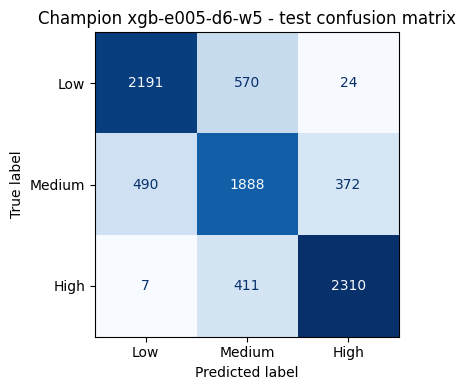

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    preds["y_true"], preds["y_pred"], labels=RISK_CLASSES,
    cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"Champion {RUN} - test confusion matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

In [6]:
# fairness slices: per-class recall by audit dimension (cells with n >= 30)
rows = []
for dim in ["gender", "race", "age_band"]:
    for value, grp in preds.groupby(dim):
        for cls in RISK_CLASSES:
            mask = grp["y_true"] == cls
            if mask.sum() >= 30:
                rec = (grp.loc[mask, "y_pred"] == cls).mean()
                rows.append({"slice": dim, "value": str(value), "class": cls,
                             "recall": round(float(rec), 3), "n": int(mask.sum())})
slices = pd.DataFrame(rows)
slices[slices["class"] == "High"].sort_values(["slice", "recall"])

,slice,value,class,recall,n
20,age_band,65-74,High,0.824,928
23,age_band,75-84,High,0.829,818
26,age_band,85+,High,0.881,438
29,age_band,<65,High,0.884,544
5,gender,Male,High,0.834,1036
2,gender,Female,High,0.855,1692
8,race,1.0,High,0.844,2250
11,race,2.0,High,0.853,300
17,race,5.0,High,0.863,80
14,race,3.0,High,0.888,98


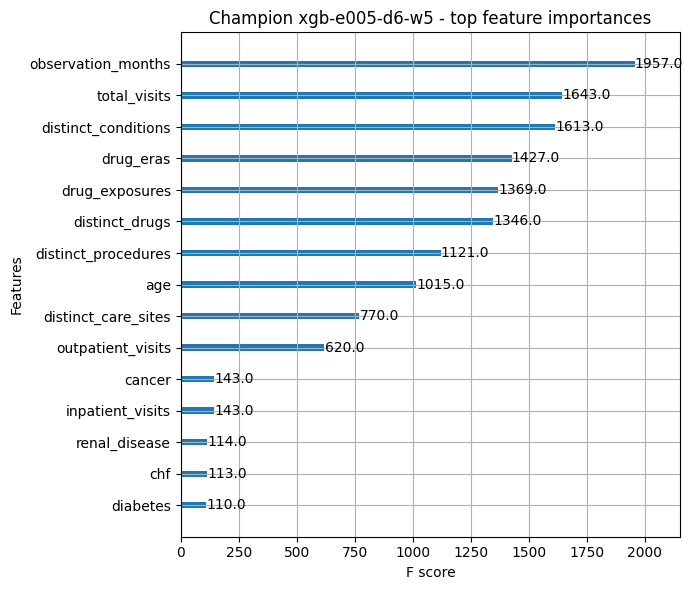

In [7]:
# champion booster feature importance (history-window signals dominate;
# the label comes from FUTURE utilization, so top slots should be chronic
# flags + visit counts, never a leakage column)
import sys
sys.path.insert(0, "src")
from model_common import encode_features, load_table
from xgboost import XGBClassifier, plot_importance

X_all, feature_names, _ = encode_features(load_table("training_table.csv"))
m = XGBClassifier()
m.load_model("champion_model.bin")
m.get_booster().feature_names = list(feature_names)

fig, ax = plt.subplots(figsize=(7, 6))
plot_importance(m.get_booster(), max_num_features=15, ax=ax)
ax.set_title(f"Champion {RUN} - top feature importances")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()

## 4. Repackage a clean champion artifact

The training tarball also carries metrics/prediction files (they share
`SM_MODEL_DIR`); a serving-ready tarball should contain only the booster,
named `model.bin` as the XGBoost container expects.

In [8]:
import shutil
import subprocess

# bsdtar (macOS) lacks GNU --transform: rename the booster to the name the
# XGBoost serving container expects, then archive it.
shutil.copy(f"champion_model{ext}", "model.bin")
subprocess.run(["tar", "-czf", "model.tar.gz", "model.bin"], check=True)
s3.upload_file("model.tar.gz", bucket,
               f"{prefix}/artifacts/models/champion/model.tar.gz")
MODEL_DATA_URL = f"s3://{bucket}/{prefix}/artifacts/models/champion/model.tar.gz"
print(f"clean artifact: {MODEL_DATA_URL}")

clean artifact: s3://sagemaker-us-east-1-685057748560/aai-540-g1/artifacts/models/champion/model.tar.gz


## 5. Model Registry — group, package, card

boto3 calls reuse the patterns debugged in Assignment 4.1 (`XGBOOST` casing,
`describe_model_package(ModelPackageName=...)`, `json.dumps` card content,
schema-compliant sections).

In [9]:
GROUP = "member-utilization-risk"
DESCRIPTION = (
    "Versioned lineage of multiclass classifiers predicting member utilization "
    "risk (Low/Medium/High) from 2008 history-window features on CMS DE-SynPUF "
    "(OMOP). A new package is added whenever algorithm, features, labels, or "
    "hyperparameters change."
)
try:
    sm_client.create_model_package_group(
        ModelPackageGroupName=GROUP, ModelPackageGroupDescription=DESCRIPTION)
    print(f"created group {GROUP}")
except sm_client.exceptions.ClientError as e:
    if "already exists" in str(e):
        print(f"group {GROUP} already exists")
    else:
        raise

created group member-utilization-risk


In [10]:
XGB_IMAGE = sagemaker.image_uris.retrieve("xgboost", region, version="1.7-1")

pkg = sm_client.create_model_package(
    ModelPackageGroupName=GROUP,
    ModelPackageDescription=(
        f"Champion run {RUN}: XGBoost 1.7-1 multiclass (multi:softprob, "
        f"num_class=3), temporal split 40/10/10/40. Validation macro F1 "
        f"{champion['val_macro_f1']:.4f}; test macro F1 "
        f"{champion['test_macro_f1']:.4f}, High-Risk recall "
        f"{champion['test_high_recall']:.4f}. Beats benchmark "
        f"({benchmark_test_f1:.4f})."),
    InferenceSpecification={
        "Containers": [{
            "Image": XGB_IMAGE,
            "ModelDataUrl": MODEL_DATA_URL,
            "Framework": "XGBOOST",
            "FrameworkVersion": "1.7-1",
        }],
        "SupportedTransformInstanceTypes": ["ml.m5.xlarge"],
        "SupportedRealtimeInferenceInstanceTypes": ["ml.m5.xlarge"],
        "SupportedContentTypes": ["text/csv"],
        "SupportedResponseMIMETypes": ["text/csv"],
    },
    ModelApprovalStatus="PendingManualApproval",
)
MODEL_PACKAGE_ARN = pkg["ModelPackageArn"]
print(MODEL_PACKAGE_ARN)

arn:aws:sagemaker:us-east-1:685057748560:model-package/member-utilization-risk/1


In [11]:
# Model card content follows the enforced JSON schema (Assignment 4.1 fix):
# six top-level sections only; hyperparameters inside training_job_details;
# extras in additional_information.custom_details.
model_card = {
    "model_overview": {
        "model_description": (
            "XGBoost gradient-boosted-trees multiclass classifier assigning CMS "
            "DE-SynPUF members a Low / Medium / High utilization-risk tier from "
            "2008 history-window features (demographics, utilization counts, "
            "chronic-condition flags, pharmacy intensity, breadth). Champion of "
            f"run {RUN}; beats both benchmark heuristics on the held-out test split."
        ),
        "model_creator": "Sourangshu Pal (AAI-540 Group 1)",
        "model_owner": "Sourangshu Pal (AAI-540 Group 1)",
        "model_artifact": [MODEL_DATA_URL],
        "algorithm_type": "XGBoost (gradient-boosted decision trees)",
        "problem_type": "Supervised multiclass classification (3 risk tiers)",
    },
    "intended_uses": {
        "purpose_of_model": (
            "Rank members by predicted utilization risk so care-management "
            "resources (nurse outreach, care coordinators) reach High-Risk "
            "members first."
        ),
        "intended_uses": (
            "ML engineers and data scientists in the AAI-540 lab pipeline. "
            "Out of scope: not a diagnostic device; scores prioritize outreach "
            "only - never coverage or pricing decisions; synthetic data means "
            "demonstrated performance does NOT transfer to real members."
        ),
        "risk_rating": "Medium",
        "explanations_for_risk_rating": (
            "Allocation ethics: missing a High-Risk member has opportunity "
            "cost; mitigated by the High-Risk recall floor, human review, and "
            "PendingManualApproval gating production use."
        ),
    },
    "training_details": {
        "objective_function": {
            "function": "Minimize",
            "facet": "multiclass log loss (mlogloss)",
            "condition": "on the temporal validation slice (course 40/10/10/40 split)",
        },
        "training_observations": (
            "Single ml.m5.2xlarge training instance; ~33k train rows x "
            f"{champ_metrics['n_features']} one-hot+count features; XGBoost "
            "early-stopped on the validation slice; fixed seed 42."
        ),
        "training_job_details": {
            "training_arn": f"see SageMaker training job {RUN}",
            "training_datasets": [
                f"s3://{bucket}/{prefix}/processed/training/training_table.csv"
            ],
            "hyper_parameters": [
                {"name": k, "value": str(v)}
                for k, v in champ_metrics["hyperparameters"].items()
            ],
        },
    },
    "evaluation_details": [{
        "name": "holdout-test",
        "evaluation_observation": (
            f"Test macro F1 {champion['test_macro_f1']:.4f}; High-Risk recall "
            f"{champion['test_high_recall']:.4f}; OvR ROC-AUC "
            f"{champion['test_roc_auc']:.4f}; benchmark B2 macro F1 "
            f"{benchmark_test_f1:.4f}. Fairness slices recorded in this notebook."
        ),
        "evaluation_job_arn": f"training job {RUN}",
    }],
    "additional_information": {
        "ethical_considerations": (
            "Synthetic public-use data (CMS DE-SynPUF); no PHI/PII. Race is "
            "excluded from features and used only as an audit slice; per-slice "
            "recall gaps are reported above."
        ),
        "caveats_and_recommendations": (
            "Labels are rule-based terciles of future utilization (relative "
            "ranking, not clinical truth). Before any real-data use: external "
            "validation, recalibration, subgroup audits, and a CMS Data Use "
            "Agreement."
        ),
        "custom_details": {
            "label_rule": ("outcome_score_v1: total_visits + 3*inpatient + "
                           "drug_eras over 2009-2010, rank terciles"),
            "split_scheme": "course 40/10/10/40 train/validation/test/production",
            "champion_run": str(RUN),
        },
    },
}
sm_client.create_model_card(
    ModelCardName=f"{GROUP}-card",
    ModelCardStatus="Draft",
    Content=json.dumps(model_card),
)
print(f"created model card {GROUP}-card")

created model card member-utilization-risk-card


## 6. 📸 Verification describes (screenshot these three outputs)

In [12]:
sm_client.describe_model_package_group(ModelPackageGroupName=GROUP)

{'ModelPackageGroupName': 'member-utilization-risk',
 'ModelPackageGroupArn': 'arn:aws:sagemaker:us-east-1:685057748560:model-package-group/member-utilization-risk',
 'ModelPackageGroupDescription': 'Versioned lineage of multiclass classifiers predicting member utilization risk (Low/Medium/High) from 2008 history-window features on CMS DE-SynPUF (OMOP). A new package is added whenever algorithm, features, labels, or hyperparameters change.',
 'CreationTime': datetime.datetime(2026, 10, 6, 21, 20, 32, 137000, tzinfo=tzlocal()),
 'CreatedBy': {'IamIdentity': {'Arn': 'arn:aws:iam::685057748560:user/final-usd',
   'PrincipalId': 'AIDAZ7AE7VZIKFWXVUDXI'}},
 'ModelPackageGroupStatus': 'Completed',
 'ResponseMetadata': {'RequestId': 'bf02d906-f342-494b-a624-39c837f1f1eb',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': 'bf02d906-f342-494b-a624-39c837f1f1eb',
   'strict-transport-security': 'max-age=47304000; includeSubDomains',
   'x-frame-options': 'DENY',
   'content-security

In [13]:
sm_client.describe_model_package(ModelPackageName=MODEL_PACKAGE_ARN)

{'ModelPackageGroupName': 'member-utilization-risk',
 'ModelPackageVersion': 1,
 'ModelPackageRegistrationType': 'Registered',
 'ModelPackageArn': 'arn:aws:sagemaker:us-east-1:685057748560:model-package/member-utilization-risk/1',
 'ModelPackageDescription': 'Champion run xgb-e005-d6-w5: XGBoost 1.7-1 multiclass (multi:softprob, num_class=3), temporal split 40/10/10/40. Validation macro F1 0.7742; test macro F1 0.7743, High-Risk recall 0.8468. Beats benchmark (0.5304).',
 'CreationTime': datetime.datetime(2026, 10, 6, 21, 20, 32, 702000, tzinfo=tzlocal()),
 'InferenceSpecification': {'Containers': [{'Image': '683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1',
    'ImageDigest': 'sha256:b4f13edb198529c460692015797fa1ca6a8ff1ed64a149297174d922121b8fc4',
    'ModelDataUrl': 's3://sagemaker-us-east-1-685057748560/aai-540-g1/artifacts/models/champion/model.tar.gz',
    'Framework': 'XGBOOST',
    'FrameworkVersion': '1.7-1',
    'ModelDataETag': '0bdbd4cf01f646282fbba495

In [14]:
sm_client.describe_model_card(ModelCardName=f"{GROUP}-card")

{'ModelCardArn': 'arn:aws:sagemaker:us-east-1:685057748560:model-card/member-utilization-risk-card',
 'ModelCardName': 'member-utilization-risk-card',
 'ModelCardVersion': 1,
 'Content': '{"model_overview": {"model_description": "XGBoost gradient-boosted-trees multiclass classifier assigning CMS DE-SynPUF members a Low / Medium / High utilization-risk tier from 2008 history-window features (demographics, utilization counts, chronic-condition flags, pharmacy intensity, breadth). Champion of run xgb-e005-d6-w5; beats both benchmark heuristics on the held-out test split.", "model_creator": "Sourangshu Pal (AAI-540 Group 1)", "model_owner": "Sourangshu Pal (AAI-540 Group 1)", "model_artifact": ["s3://sagemaker-us-east-1-685057748560/aai-540-g1/artifacts/models/champion/model.tar.gz"], "algorithm_type": "XGBoost (gradient-boosted decision trees)", "problem_type": "Supervised multiclass classification (3 risk tiers)"}, "intended_uses": {"purpose_of_model": "Rank members by predicted utilizat